In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 120.7 MB/s eta 0:00:00


In [4]:

!pip install roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="k9JZoqYgrrFR2uhZyViM")
project = rf.workspace("dias-workspplace").project("datasets_merges_fridge-pq54a")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to datasets_merges_fridge-1 in yolov8:: 100%|██████████| 39377/39377 [00:07<00:00, 4944.48it/s]


In [ ]:
import os

print("Files in dataset root:")
print(os.listdir(dataset.location))

print("\nTrain folders:")
print(os.listdir(os.path.join(dataset.location, "train")))

print("\nValid folders:")
print(os.listdir(os.path.join(dataset.location, "valid")))

print("\nTest folders:")
print(os.listdir(os.path.join(dataset.location, "test")))

Files in dataset root:
['README.dataset.txt', 'data.yaml', 'README.roboflow.txt', 'train', 'valid', 'test']

Train folders:
['images', 'labels', 'labels.cache']

Valid folders:
['images', 'labels', 'labels.cache']

Test folders:
['images', 'labels']


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

results_phase1 = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    patience=10,
    pretrained=True,
    freeze=10,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    cos_lr=True,
    cache=True,
    workers=2,
    amp=True,
    project="/content/drive/MyDrive/CV_models",
    name="fridge_phase1",
    exist_ok=True,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5,
    translate=0.08,
    scale=0.2,
    fliplr=0.5,
    mosaic=0.5,
    mixup=0.1,
    close_mosaic=10
)

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/datasets_merges_fridge-1/data.yaml, degrees=5, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=fridge_phase1, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=Tr

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO("/content/drive/MyDrive/CV_models/fridge_phase1/weights/best.pt")

results_phase2 = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    patience=20,
    pretrained=True,
    freeze=0,
    optimizer="AdamW",
    lr0=0.0003,
    lrf=0.01,
    weight_decay=0.0005,
    cos_lr=True,
    cache=True,
    workers=2,
    amp=True,
    project="/content/drive/MyDrive/CV_models",
    name="fridge_phase2",
    exist_ok=True,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5,
    translate=0.08,
    scale=0.2,
    fliplr=0.5,
    mosaic=0.3,
    mixup=0.05,
    close_mosaic=15
)

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/datasets_merges_fridge-1/data.yaml, degrees=5, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=/content/drive/MyDrive/CV_models/fridge_phase1/weights/best.pt, momentum=0.937, mosaic=0.3, multi_scale=0.0, name=fridge_phase2, nbs=64, nms=False, opset=N

In [ ]:
best_model = YOLO("/content/drive/MyDrive/CV_models/fridge_phase2/weights/best.pt")

metrics = best_model.val(
    data=f"{dataset.location}/data.yaml",
    split="val",
    imgsz=640,
    conf=0.25
)

print(metrics)

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,418,218 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 27.0±14.3 MB/s, size: 53.4 KB)
val: Scanning /content/datasets_merges_fridge-1/valid/labels.cache... 1247 images, 541 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1247/1247 290.6Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 254, len(boxes) = 2477. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 78/78 4.3it/s 18.1s
                   all       1247       2477      0.581      0.319      0.283      0.211
                 apple         29         53      0.297      0.302      0.244      0.178
                ba

Testing on: /content/datasets_merges_fridge-1/test/images/877f35f68509768c_jpg.rf.98fa9050f429e2b3f98e76f540f3695a.jpg

image 1/1 /content/datasets_merges_fridge-1/test/images/877f35f68509768c_jpg.rf.98fa9050f429e2b3f98e76f540f3695a.jpg: 640x640 (no detections), 15.6ms
Speed: 2.5ms preprocess, 15.6ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-187
Predicted image saved at: /content/runs/detect/predict-187/877f35f68509768c_jpg.rf.98fa9050f429e2b3f98e76f540f3695a.jpg

Total objects detected: 0

Counts per class:


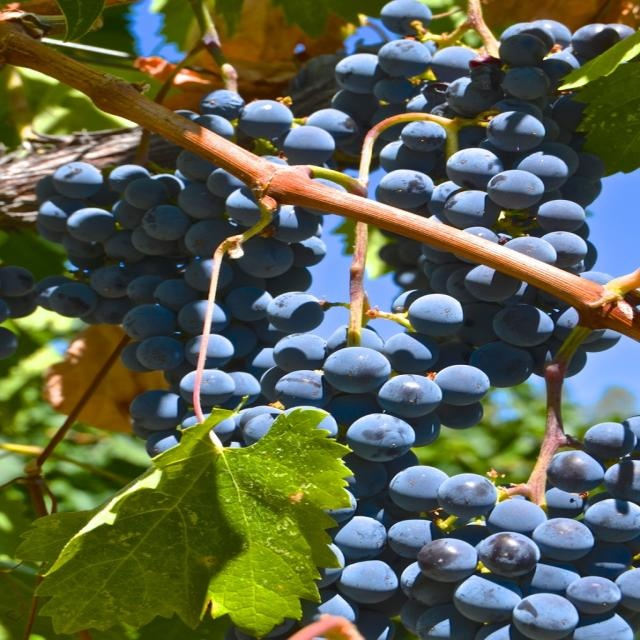

In [ ]:
from ultralytics import YOLO
from IPython.display import display, Image
from collections import Counter
import os, glob, random

model = YOLO("/content/drive/MyDrive/CV_models/fridge_phase2/weights/best.pt")

test_images_dir = os.path.join(dataset.location, "test", "images")
image_list = glob.glob(os.path.join(test_images_dir, "*"))
test_image = random.choice(image_list)

print("Testing on:", test_image)

results = model.predict(
    source=test_image,
    conf=0.25,
    iou=0.45,
    save=True
)

predicted_image_path = os.path.join(results[0].save_dir, os.path.basename(test_image))
print("Predicted image saved at:", predicted_image_path)

boxes = results[0].boxes
total_objects = len(boxes)

class_ids = [int(box.cls[0]) for box in boxes]
class_names = [model.names[i] for i in class_ids]
counts = Counter(class_names)

print("\nTotal objects detected:", total_objects)
print("\nCounts per class:")
for name, count in counts.items():
    print(f"{name}: {count}")

display(Image(filename=predicted_image_path))

Adding calories count


Testing on: /content/datasets_merges_fridge-1/test/images/00760b4613f18ee9_jpg.rf.37dff80cb226339d5cbdfd37c4b5f8fe.jpg
Results saved to /content/runs/detect/predict-38
Predicted image saved at: /content/runs/detect/predict-38/00760b4613f18ee9_jpg.rf.37dff80cb226339d5cbdfd37c4b5f8fe.jpg

Total objects detected: 1

Counts per class:
orange: 1

Estimated calories per detected object:
1. orange (conf=0.96) -> ~86.8 kcal

Total estimated calories of detected objects only: ~86.8 kcal


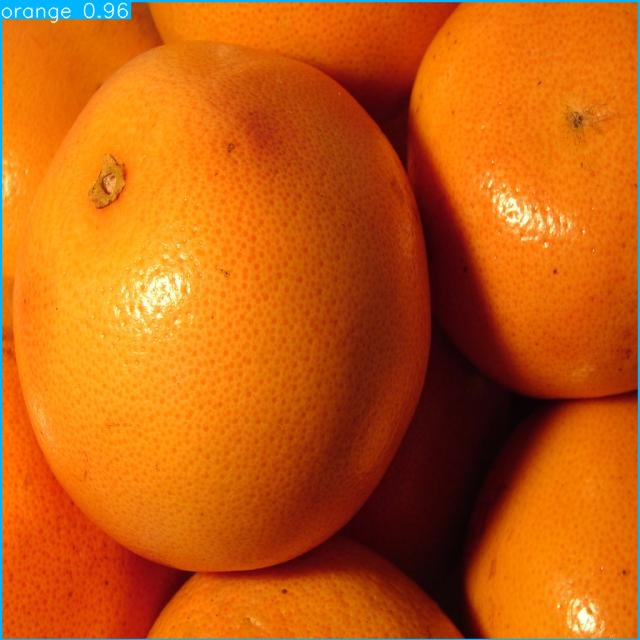

In [42]:
from ultralytics import YOLO
from IPython.display import display, Image
from collections import Counter
import os, glob, random, math

model = YOLO("/content/drive/MyDrive/CV_models/fridge_phase2/weights/best.pt")

CALORIE_BASE = {
    "apple": 95,
    "banana": 105,
    "orange": 62,
    "pear": 101,
    "tomato": 22,
    "carrot": 25,
    "broccoli": 50,
    "bell_pepper": 31,
    "cabbage": 200,
    "egg": 78,
    "milk": 150,
    "yogurt": 120,
    "cheese": 113,
    "water_bottle": 0,
    "juice": 110
}


REFERENCE_AREA = {
    "apple": 35000,
    "banana": 50000,
    "orange": 30000,
    "pear": 35000,
    "tomato": 22000,
    "carrot": 18000,
    "broccoli": 40000,
    "bell_pepper": 28000,
    "cabbage": 70000,
    "egg": 12000,
    "milk": 45000,
    "yogurt": 25000,
    "cheese": 22000,
    "water_bottle": 40000,
    "juice": 35000
}

SIZE_ADJUSTED_CLASSES = {"banana", "apple", "orange", "pear", "tomato", "carrot",
                         "broccoli", "bell_pepper", "cabbage", "cheese", "yogurt"}

def estimate_object_calories(class_name, x1, y1, x2, y2):
    base = CALORIE_BASE.get(class_name, 0)


    if class_name not in SIZE_ADJUSTED_CLASSES:
        return round(base, 1)

    ref_area = REFERENCE_AREA.get(class_name, 30000)
    box_area = max((x2 - x1), 1) * max((y2 - y1), 1)


    size_factor = math.sqrt(box_area / ref_area)


    size_factor = max(0.7, min(size_factor, 1.4))

    return round(base * size_factor, 1)


test_images_dir = os.path.join(dataset.location, "test", "images")

image_list = []
for ext in ["*.jpg", "*.jpeg", "*.png", "*.webp"]:
    image_list.extend(glob.glob(os.path.join(test_images_dir, ext)))

if not image_list:
    raise ValueError(f"No test images found in {test_images_dir}")

test_image = random.choice(image_list)
print("Testing on:", test_image)

results = model.predict(
    source=test_image,
    conf=0.25,
    iou=0.45,
    save=True,
    verbose=False
)

predicted_image_path = os.path.join(results[0].save_dir, os.path.basename(test_image))
print("Predicted image saved at:", predicted_image_path)

boxes = results[0].boxes
total_objects = len(boxes)

class_ids = [int(box.cls[0]) for box in boxes]
class_names = [model.names[i] for i in class_ids]
counts = Counter(class_names)

print("\nTotal objects detected:", total_objects)

if total_objects == 0:
    print("\nNo objects detected.")
else:
    print("\nCounts per class:")
    for name, count in sorted(counts.items()):
        print(f"{name}: {count}")

    detected_items = []
    total_calories = 0

    print("\nEstimated calories per detected object:")
    for idx, box in enumerate(boxes, start=1):
        cls_id = int(box.cls[0].item())
        class_name = model.names[cls_id]
        conf = float(box.conf[0].item())

        x1, y1, x2, y2 = box.xyxy[0].tolist()
        calories = estimate_object_calories(class_name, x1, y1, x2, y2)

        detected_items.append({
            "index": idx,
            "class": class_name,
            "confidence": round(conf, 2),
            "calories": calories,
            "bbox": [round(x1, 1), round(y1, 1), round(x2, 1), round(y2, 1)]
        })

        total_calories += calories
        print(f"{idx}. {class_name} (conf={conf:.2f}) -> ~{calories} kcal")

    print(f"\nTotal estimated calories of detected objects only: ~{round(total_calories, 1)} kcal")

display(Image(filename=predicted_image_path))